# UFood Campaign Analysis 

## Business Context - What are we solving?
**UFood** is the leading food delivery app in Brazil, operating in over 1,000 cities. They sell products from five
categories — **wines, meat products, exotic fruits, fish, and sweet products** — through three channels:
physical stores, catalogues, and a website. A 'gold' premium tier exists alongside regular products.
Despite strong past revenue, profit growth for the next three years looks weak. The marketing team ran 5
campaigns and needs to understand what worked, who responded, and how to target future campaigns
more effectively.

**The three objectives from the case brief**:

• Explore the data deeply — go beyond averages. Find cause and effect.

• Propose a customer segmentation based on spending behaviour.

• Visualise findings and explain the reasoning behind each insight.

## Research Questions
1. Which customer segments spend the most money?
2. What customer traits predict campaign acceptance?
3. Which product categories drive the most revenue?
4. Which purchase channels are most used?
5. How do discount-heavy buyers differ from full-price buyers?
6. Can customers be grouped into meaningful segments?

## Hypotheses to Test

1. Higher-income customers spend more across all categories.
2. Customers with children at home (kidhome or Teenhome >0) accept fewer campaigns.
3. Customers who accepted more past campaigns are more likely to accept the last one.
4. Lower recency (bought recently) is linked to higher campaign acceptance.
5. Catalogue buyers have a higher average total spend than web or store buyers.
6. Education level influences which product categories customers prefer.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme(style = 'whitegrid', palette = 'muted')

In [52]:
pd.set_option('display.max_rows', 2100)
pd.set_option('display.max_columns', 50)

In [2]:
food = pd.read_csv(r'C:\Users\avise\OneDrive\Desktop\Python\Analyst Builder\Food Marketing Data Analysis\u_food_marketing.csv')

In [3]:
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [4]:
food.tail()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
2200,61223.0,0,1,46,709,43,182,42,118,247,...,0,0,0,0,1,0,0,1094,847,0
2201,64014.0,2,1,56,406,0,30,0,0,8,...,1,0,0,0,0,0,1,436,428,1
2202,56981.0,0,0,91,908,48,217,32,12,24,...,0,0,0,0,1,0,0,1217,1193,1
2203,69245.0,0,1,8,428,30,214,80,30,61,...,1,0,0,0,0,1,0,782,721,0
2204,52869.0,1,1,40,84,3,61,2,1,21,...,0,0,0,0,0,0,1,151,130,0


In [7]:
food.sample(5)

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
52,70287.0,0,0,30,295,35,482,121,120,40,...,0,0,0,0,1,0,0,1053,1013,0
154,62551.0,0,0,27,125,16,98,134,21,27,...,0,0,0,0,1,0,0,394,367,1
879,21846.0,1,0,38,7,17,18,6,10,26,...,0,0,0,0,1,0,0,58,32,0
59,70666.0,0,0,29,398,40,367,119,122,30,...,1,0,0,0,1,0,0,1046,1016,0
1275,60033.0,0,1,28,62,1,57,19,11,48,...,1,0,0,0,0,1,0,150,102,0


So far, we have imported all the necessary libraries and the dataset. After that, we inspected the data a bit. 
The next step will be moving to the Exploratory Data Analysis. 

In [8]:
food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

# Exploratory Data Analysis

In [11]:
food[food.duplicated(keep = False)]

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
14,82800.0,0,0,23,1006,22,115,59,68,45,...,0,0,0,0,0,0,1,1270,1225,2
16,37760.0,0,0,20,84,5,38,150,12,28,...,1,0,0,0,1,0,0,289,261,0
22,65324.0,0,1,0,384,0,102,21,32,5,...,0,0,0,0,0,0,1,539,534,0
23,40689.0,0,1,69,270,3,27,39,6,99,...,1,0,0,0,1,0,0,345,246,0
27,84618.0,0,0,96,684,100,801,21,66,0,...,0,0,0,0,0,0,1,1672,1672,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,22775.0,1,0,40,5,1,8,0,0,1,...,1,0,0,0,1,0,0,14,13,0
2188,75777.0,0,0,12,712,26,538,69,13,80,...,0,0,0,0,0,1,0,1358,1278,2
2192,58554.0,1,1,55,368,24,68,38,0,88,...,1,0,0,0,1,0,0,498,410,0
2199,34421.0,1,0,81,3,3,7,6,2,9,...,0,0,0,0,1,0,0,21,12,0


In [14]:
food = food.drop_duplicates()

In [15]:
food.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2021 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2021 non-null   float64
 1   Kidhome               2021 non-null   int64  
 2   Teenhome              2021 non-null   int64  
 3   Recency               2021 non-null   int64  
 4   MntWines              2021 non-null   int64  
 5   MntFruits             2021 non-null   int64  
 6   MntMeatProducts       2021 non-null   int64  
 7   MntFishProducts       2021 non-null   int64  
 8   MntSweetProducts      2021 non-null   int64  
 9   MntGoldProds          2021 non-null   int64  
 10  NumDealsPurchases     2021 non-null   int64  
 11  NumWebPurchases       2021 non-null   int64  
 12  NumCatalogPurchases   2021 non-null   int64  
 13  NumStorePurchases     2021 non-null   int64  
 14  NumWebVisitsMonth     2021 non-null   int64  
 15  AcceptedCmp3          2021

In [24]:
food.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.0,2021.0,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000
mean,51687.258783,0.443345,0.509649,48.880752,306.492331,26.364671,166.059871,37.603662,27.268679,43.921821,2.330035,4.115289,2.644730,5.807521,5.340426,0.074715,0.076695,0.072241,0.065809,0.012865,0.009401,3.0,11.0,0.153884,51.117269,2511.613063,0.105888,0.388422,0.219198,0.251856,0.034636,0.090549,0.024245,0.502227,0.165760,0.217219,563.789213,519.867392,0.302326
std,20713.046401,0.536196,0.546393,28.950917,337.603877,39.776518,219.869126,54.892196,41.575454,51.678211,1.892778,2.753588,2.799126,3.230434,2.426319,0.262997,0.266172,0.258951,0.248009,0.112720,0.096527,0.0,0.0,0.360927,11.667616,202.546762,0.307771,0.487512,0.413806,0.434186,0.182902,0.287038,0.153848,0.500119,0.371957,0.412455,576.775749,554.797857,0.680812
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,24.000000,2159.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.000000
25%,35416.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,43.000000,2337.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,42.000000,0.000000
50%,51412.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,50.000000,2511.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.000000
75%,68274.000000,1.000000,1.000000,74.000000,507.000000,33.000000,230.000000,50.000000,34.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,61.000000,2688.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,883.000000,0.000000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,80.000000,2858.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.000000


In [21]:
food[food['Income']== 0]

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall


In [22]:
food['Age'].max()

80

In [32]:
spend_cols = ['MntFishProducts', 'MntMeatProducts', 'MntFruits', 'MntSweetProducts', 'MntWines', 'MntGoldProds']
calculated_total = food[spend_cols].sum(axis=1)
match = calculated_total.equals(food['MntTotal'])
print('MntTotals matches sum of spend cols:' , match)

MntTotals matches sum of spend cols: False


In [36]:
food['TotalSpend'] = food[spend_cols].sum(axis=1)

I created a new column **TotalSpend** which sums all 6 product categories, including gold products. The pre-built **MntTotal** column excludes gold 
products, so I calculated my own total to capture the full picture of customer spending. 

In [33]:
cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
calculated_overall = food[cmp_cols].sum(axis = 1)
match = calculated_overall.equals(food['AcceptedCmpOverall'])
print('AcceptedCmpOverall matches sum of all the campaigns:' , match)

AcceptedCmpOverall matches sum of all the campaigns: False


In [38]:
food['TotalCampaignAccepted'] = food[cmp_cols].sum(axis=1)

**AcceptedCmpOverall** counts only campaigns 1–5. I created **TotalCampaignAccepted**, which includes the last campaign (Response) to measure each customer's total engagement across all 6 campaigns.

For further analysis, I will be using **TotalSpend** and **TotalCampaignAccepted** as they are the actual totals. I feel they are going to potray a better picture for my analysis. 

Several columns serve the same purpose, so I have decided to merge them so that I can have a better analysis. For example, instead of working with raw Age numbers, I can group them into 'Young', 'Mid', and 'Senior'. It will make group-by analysis much cleaner. The same thing can be done with the Income, which will portray a better picture of Income distribution. 

In [41]:
food['AgeGroup'] = pd.cut(food['Age'],
                       bins = [0, 35, 50, 65, 100],
                       labels = ['Young (18-35)', 'Mid (36- 50)', 'Senior (51-65)', 'Elder (65+)'])

In [42]:
food['AgeGroup'].value_counts()

AgeGroup
Mid (36- 50)      855
Senior (51-65)    685
Elder (65+)       285
Young (18-35)     196
Name: count, dtype: int64

In [43]:
food['IncomeGroup'] = pd.qcut(food['Income'], 
                             q = 4,
                             labels = ['Low', 'Mid-Low', 'Mid-High', 'High'])

In [44]:
food['IncomeGroup'].value_counts()

IncomeGroup
Low         506
Mid-Low     505
Mid-High    505
High        505
Name: count, dtype: int64

In [45]:
food['HasKids'] = food['Kidhome'] + food['Teenhome']

In [46]:
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,...,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,TotalSpend,TotalCampaignAccepted,AgeGroup,IncomeGroup,HasKids
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,...,63,2822,0,0,1,0,0,0,0,1,0,0,1529,1441,0,1617,1,Senior (51-65),Mid-High,0
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,...,66,2272,0,0,1,0,0,0,0,1,0,0,21,15,0,27,0,Elder (65+),Mid-Low,2
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,...,55,2471,0,0,0,1,0,0,0,1,0,0,734,692,0,776,0,Senior (51-65),High,0
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,...,36,2298,0,0,0,1,0,0,0,1,0,0,48,43,0,53,0,Mid (36- 50),Low,1
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,...,39,2320,0,1,0,0,0,0,0,0,0,1,407,392,0,422,0,Mid (36- 50),Mid-High,1


In [49]:
food['marital_Divorced'] = food['marital_Divorced'].replace({1:5,0:0})
food['marital_Married'] = food['marital_Married'].replace({1:4,0:0})
food['marital_Single'] = food['marital_Single'].replace({1:3,0:0})
food['marital_Together'] = food['marital_Together'].replace({1:2,0:0})
food['marital_Widow'] = food['marital_Widow'].replace({1:1,0:0})

In [50]:
food['marital_Status'] = food[['marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow']].sum(axis=1)

In [54]:
food.sample(10)

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,TotalSpend,TotalCampaignAccepted,AgeGroup,IncomeGroup,HasKids,marital_Status,marital_Status_str
1113,85606.0,0,1,89,717,42,864,219,30,84,2,6,7,9,3,0,0,0,1,0,0,3,11,0,44,2753,0,0,0,2,0,0,0,1,0,0,1872,1788,1,1956,1,Mid (36- 50),High,1,2,Together
911,46107.0,1,0,78,31,9,27,16,9,33,1,1,1,4,3,0,0,0,0,0,0,3,11,0,31,2298,0,0,3,0,0,0,0,1,0,0,92,59,0,125,0,Young (18-35),Mid-Low,1,3,Single
856,42835.0,1,1,64,379,4,93,12,9,98,7,6,6,4,6,0,0,0,0,0,0,3,11,0,49,2523,5,0,0,0,0,0,0,0,1,0,497,399,0,595,0,Mid (36- 50),Mid-Low,2,5,Divorced
1434,38410.0,0,0,65,153,64,123,116,64,14,2,5,2,9,6,0,0,0,0,0,0,3,11,1,46,2812,0,4,0,0,0,0,0,0,0,1,520,506,0,534,1,Mid (36- 50),Mid-Low,0,4,Married
2039,77610.0,0,1,70,1245,33,332,21,33,16,2,4,7,4,7,0,0,0,0,0,0,3,11,0,68,2767,0,4,0,0,0,0,0,0,0,1,1664,1648,0,1680,0,Elder (65+),High,1,4,Married
1513,71969.0,0,1,59,1000,0,76,0,0,10,3,3,4,9,8,0,1,0,0,0,0,3,11,0,49,2780,0,4,0,0,0,0,0,0,0,1,1076,1066,1,1086,1,Mid (36- 50),High,1,4,Married
2010,75330.0,1,1,94,555,82,257,93,61,61,4,10,3,12,6,0,0,0,0,0,0,3,11,0,43,2792,0,4,0,0,0,0,0,1,0,0,1048,987,0,1109,0,Mid (36- 50),High,2,4,Married
2202,56981.0,0,0,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0,39,2314,5,0,0,0,0,0,0,1,0,0,1217,1193,1,1241,1,Mid (36- 50),Mid-High,0,5,Divorced
1187,18351.0,0,0,1,1,12,9,0,14,7,1,2,0,3,7,0,0,0,0,0,0,3,11,0,30,2402,0,4,0,0,0,0,0,1,0,0,36,29,0,43,0,Young (18-35),Low,0,4,Married
1902,64849.0,0,0,42,652,48,350,94,84,108,1,9,3,6,5,0,0,0,0,0,0,3,11,1,63,2752,0,0,3,0,0,0,0,1,0,0,1228,1120,0,1336,1,Senior (51-65),Mid-High,0,3,Single


In [53]:
food['marital_Status_str'] = food['marital_Status'].map({5: 'Divorced', 4: 'Married', 3: 'Single', 2: 'Together', 1: 'Widow'})

In [55]:
food['education_2n Cycle'] = food['education_2n Cycle'].replace({1:1,0:0})
food['education_Basic'] = food['education_Basic'].replace({1:2,0:0})
food['education_Graduation'] = food['education_Graduation'].replace({1:3,0:0})
food['education_Master'] = food['education_Master'].replace({1:4,0:0})
food['education_PhD'] = food['education_PhD'].replace({1:5,0:0})

In [56]:
food['education_Status'] = food[['education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD']].sum(axis=1)

In [57]:
food.sample(5)

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,TotalSpend,TotalCampaignAccepted,AgeGroup,IncomeGroup,HasKids,marital_Status,marital_Status_str,education_Status
2194,57967.0,0,1,39,229,7,137,4,0,91,5,4,2,8,5,0,0,0,0,0,0,3,11,0,58,2642,0,0,3,0,0,0,0,3,0,0,377,286,0,468,0,Senior (51-65),Mid-High,1,3,Single,3
613,65488.0,0,0,46,603,45,207,36,18,54,1,3,4,6,1,0,0,0,0,0,0,3,11,0,62,2175,0,0,0,2,0,0,0,0,0,5,909,855,0,963,0,Senior (51-65),Mid-High,0,2,Together,5
2174,32144.0,1,1,76,41,0,10,0,0,3,4,2,1,3,7,0,1,0,0,0,0,3,11,0,66,2257,0,0,0,2,0,0,0,3,0,0,51,48,1,54,1,Elder (65+),Low,2,2,Together,3
21,58607.0,0,1,63,867,0,86,0,0,19,3,2,3,9,8,0,1,0,0,0,0,3,11,0,71,2712,0,4,0,0,0,0,0,0,0,5,953,934,1,972,1,Elder (65+),Mid-High,1,4,Married,5
1052,59925.0,0,1,83,473,21,176,19,21,56,3,9,2,9,6,0,0,0,0,0,0,3,11,0,65,2735,0,0,0,2,0,0,0,3,0,0,710,654,0,766,0,Senior (51-65),Mid-High,1,2,Together,3


# Spending Analysis - Who Spends What?

Spending analysis is the core of this project. UFood needs to know which customers spend the most, and on what. We use groupby() to split customers into groups and .mean() or .sum() to compare those groups.

In [126]:
# Overall Spend by Product Category
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
avg_spend = food[spend_cols].mean().sort_values(ascending = False)
avg_spend


MntWines            306.492331
MntMeatProducts     166.059871
MntGoldProds         43.921821
MntFishProducts      37.603662
MntSweetProducts     27.268679
MntFruits            26.364671
dtype: float64

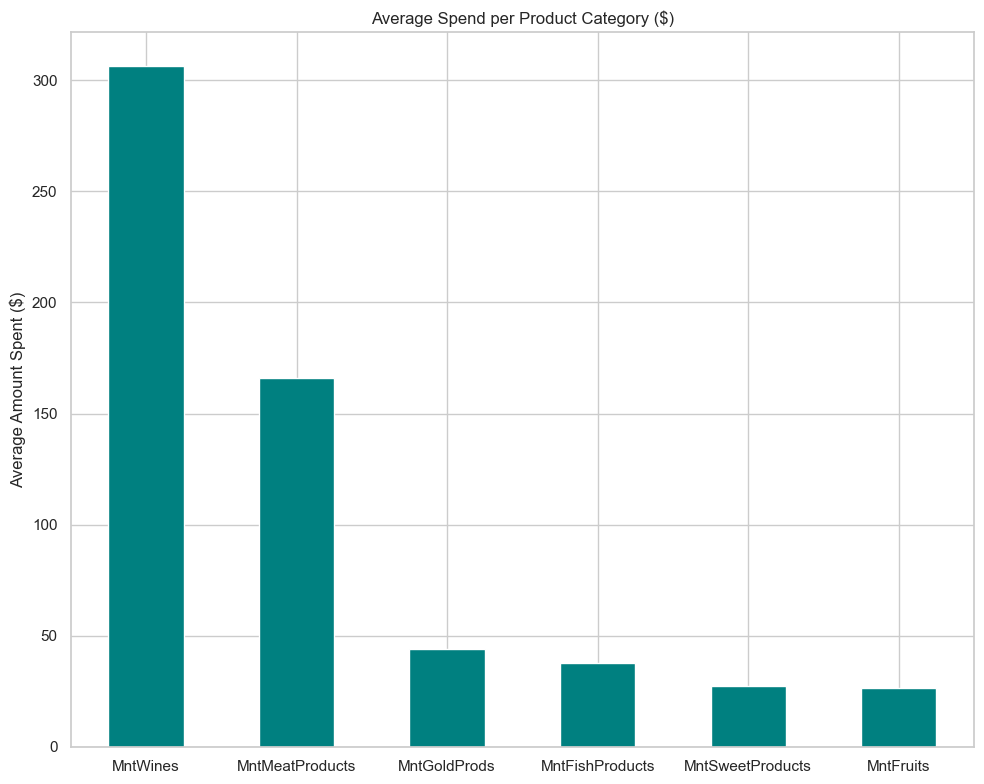

In [128]:
avg_spend.plot(kind = 'bar', figsize = (10,8), color = 'teal', title = 'Average Spend per Product Category ($)')
plt.ylabel('Average Amount Spent ($)')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

The chart shows the average amount customers spend in each product category. **Wine** has by far the highest average spend, followed by **meat products**. All other categories—**gold, fish, sweets, and fruits**—have much lower spending levels. This indicates that **wine and meat are the primary drivers of product revenue**, while the remaining categories contribute relatively little.

In [131]:
# Spend by Income Group 
spend_by_income_groups = food.groupby('IncomeGroup', observed = True)['TotalSpend'].mean().round(2)
spend_by_income_groups

IncomeGroup
Low           83.30
Mid-Low      231.57
Mid-High     747.61
High        1369.40
Name: TotalSpend, dtype: float64

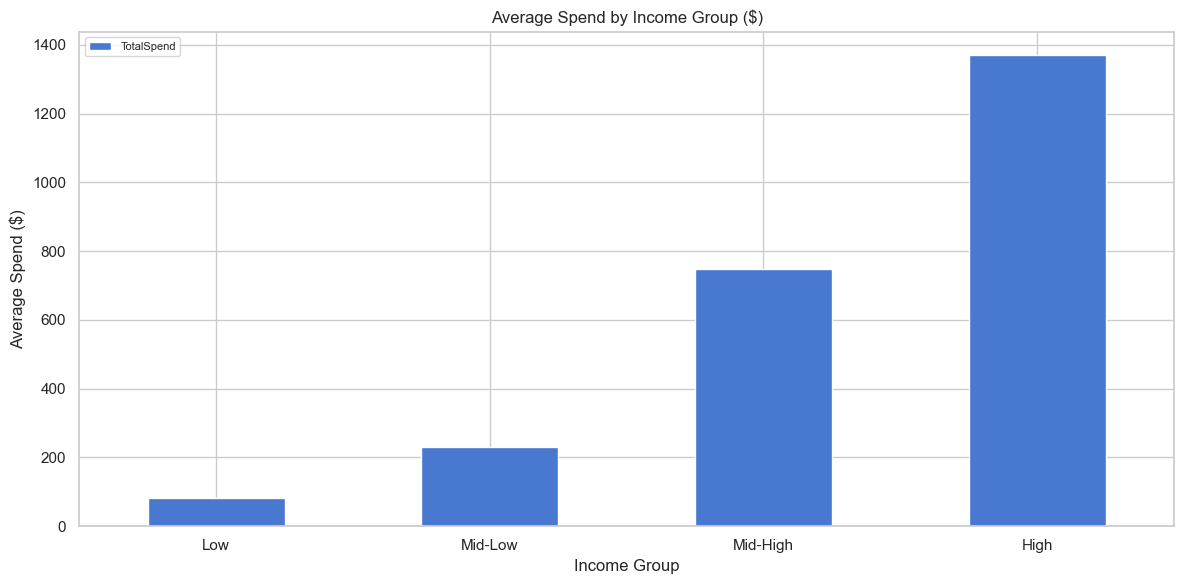

In [133]:
spend_by_income_groups.plot(kind='bar', figsize=(12, 6), title='Average Spend by Income Group ($)')
plt.ylabel('Average Spend ($)')
plt.xlabel('Income Group')
plt.xticks(rotation=0)
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

**Average spending rises sharply with income.** Low‑income customers spend the least, while Mid‑Low and Mid‑High groups show steady increases. The High‑income group stands out with the highest average spend—over **$1,300**—indicating a strong positive relationship between income level and total spending.

In [135]:
# Spend by Whether Customer Has Kids
kids_impact_on_spending = food.groupby('HasKids')['TotalSpend'].mean().round(2)
kids_impact_on_spending

HasKids
0    1120.52
1     473.28
2     249.10
3     258.60
Name: TotalSpend, dtype: float64

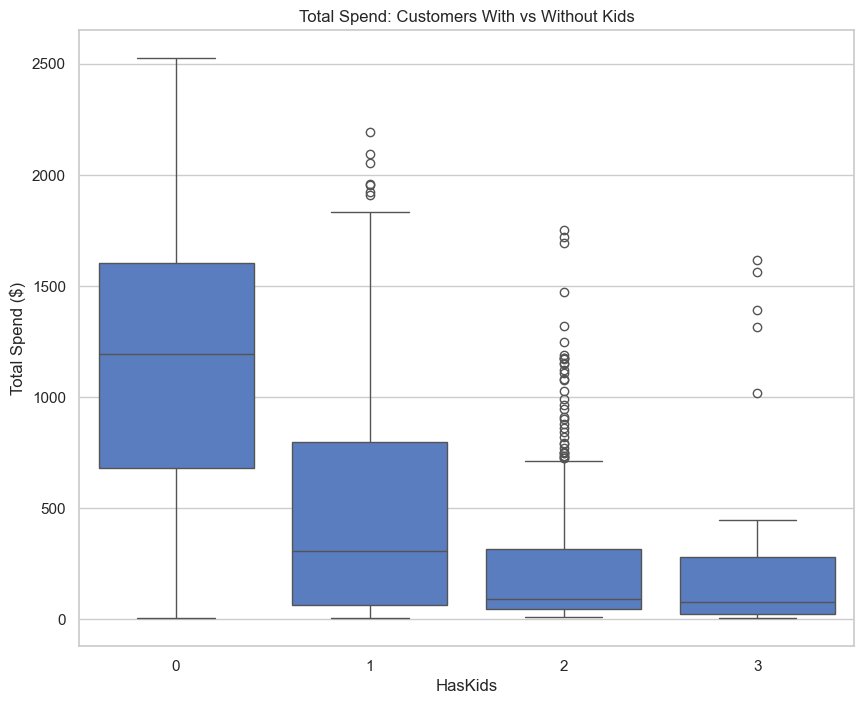

In [137]:
plt.figure(figsize = (10,8))
sns.boxplot(x= 'HasKids', y = 'TotalSpend', data = food)
plt.title('Total Spend: Customers With vs Without Kids')
plt.ylabel('Total Spend ($)')
plt.show()

Customers **without kids** spend the most on average, with total spend dropping sharply as the number of kids increases. The boxplot shows that child‑free customers not only spend more but also have greater variability and more high‑spending outliers. In contrast, customers with 1–3 kids spend significantly less, suggesting that larger families have tighter budgets and lower discretionary spending.

In [139]:
# Spend by Education Level
education_spend = food.groupby('education_Status')['TotalSpend'].mean().round()
education_spend

education_Status
1    501.0
2     84.0
3    624.0
4    620.0
5    664.0
Name: TotalSpend, dtype: float64

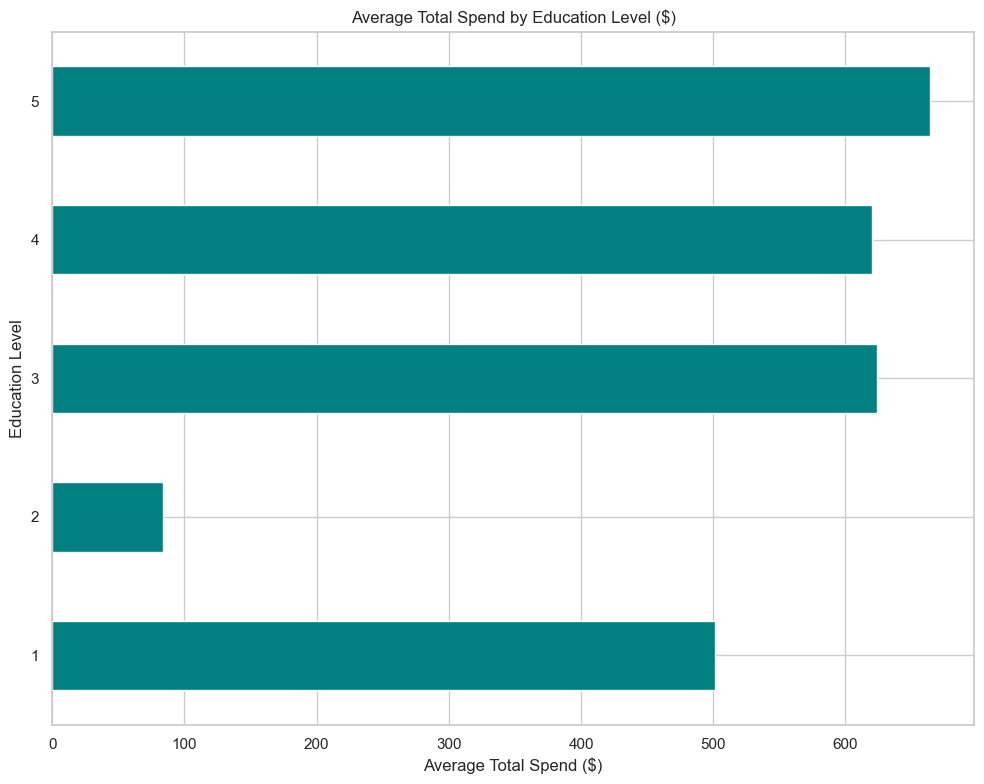

In [143]:
education_spend.plot(kind = 'barh', figsize= (10,8), color = 'teal', title = 'Average Total Spend by Education Level ($)')
plt.xlabel('Average Total Spend ($)')
plt.ylabel('Education Level')
plt.tight_layout()
plt.show()

**Average spending varies noticeably by education level.** Customers in the higher education groups (levels 3, 4, and 5) spend the most—around \$620–\$664—while those in the lowest education group spend far less, averaging only \$84. This pattern suggests that higher education is associated with higher purchasing power and greater overall spending.

Note: Education Level 1: 2n Cycle, 2: Basic, 3: Graduation, 4: Master, 5: PhD.

### Spending Analysis — Who Spends What?

**Wines and Meat dominate product spending — everything else is a distant third.**

Wines are the single highest-spending category. Gold products ($45), fish ($37), sweets ($28), and fruits ($27) are all significantly lower and relatively close to each other. This means nearly 70% of the average customer's category spend is concentrated in just two products. Wine and meat promotions would have the broadest revenue impact across the customer base.

**Income is the strongest driver of total spending.**

The income group analysis reveals a steep and consistent spending gradient across all four groups:

High-income customers spend **16x more** than low-income customers on average. Notably, the jump from Mid-Low to Mid-High is the largest proportional increase — suggesting that crossing into the upper half of the income distribution triggers a significant shift in discretionary spending behaviour. 

**Key Takeaway**

Spending at UFood is shaped by three compounding factors: income, family structure, and, to a lesser extent, education. A child-free, high-income customer spends more than 13x the amount of a low-income customer with multiple children. These are not independent — higher education tends to correlate with higher income, and having more children correlates with less discretionary spending. The marketing team should consider all three dimensions together when identifying high-value targets, not income alone.

# Campaign Analysis - Who Responds and Why?

Campaign analysis tells UFood which campaigns worked and which types of customers responded. The Response column is the most important - that is, the outcome UFood most wants to predict. We compare responders vs non-responders across income, recency, age, and spending to find which features separate the two groups.

In [64]:
food[food['TotalCampaignAccepted'] > 1].sort_values('TotalCampaignAccepted', ascending = False).head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,TotalSpend,TotalCampaignAccepted,AgeGroup,IncomeGroup,HasKids,marital_Status,marital_Status_str,education_Status
1067,84460.0,0,0,80,152,27,103,106,54,81,0,9,9,4,5,0,1,1,1,1,0,3,11,1,62,2700,0,0,0,2,0,0,0,0,0,5,442,361,4,523,5,Senior (51-65),High,0,2,Together,5
542,87771.0,0,1,61,1492,38,287,50,57,33,1,5,10,4,6,0,1,1,1,1,0,3,11,1,61,2562,0,0,0,2,0,0,0,3,0,0,1924,1891,4,1957,5,Senior (51-65),High,1,2,Together,3
1684,83512.0,0,0,31,1060,61,835,80,20,101,1,4,7,10,1,1,0,1,1,1,0,3,11,1,34,2171,0,4,0,0,0,0,0,3,0,0,2056,1955,4,2157,5,Young (18-35),High,0,4,Married,3
238,102692.0,0,0,5,168,148,444,32,172,148,1,6,9,13,2,0,1,1,1,1,0,3,11,1,46,2609,5,0,0,0,0,0,0,3,0,0,964,816,4,1112,5,Mid (36- 50),High,0,5,Divorced,3
1287,65169.0,0,0,23,1074,0,69,0,0,46,1,10,4,13,6,1,0,1,1,1,0,3,11,1,38,2325,0,4,0,0,0,0,0,3,0,0,1143,1097,4,1189,5,Mid (36- 50),Mid-High,0,4,Married,3


In [63]:
food['TotalCampaignAccepted'].value_counts().sort_index()

TotalCampaignAccepted
0    1458
1     344
2     130
3      47
4      33
5       9
Name: count, dtype: int64

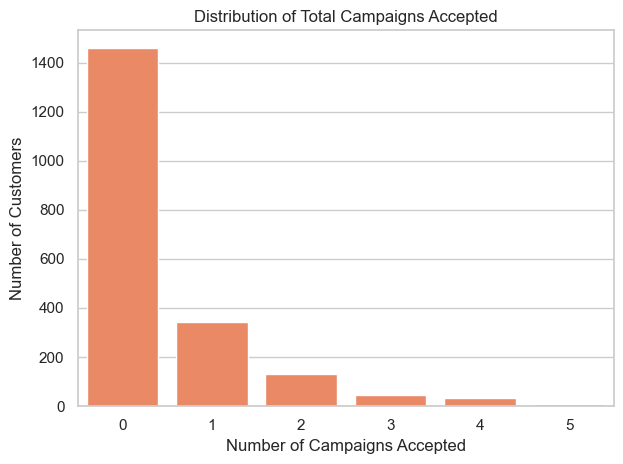

In [69]:
sns.countplot(data = food, x = 'TotalCampaignAccepted', color = 'coral')
plt.title('Distribution of Total Campaigns Accepted')
plt.xlabel('Number of Campaigns Accepted')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Most customers did not accept any marketing campaigns. Out of all customers, 1458 accepted 0 campaigns, while only a small fraction accepted multiple campaigns (e.g., 344 accepted 1, 130 accepted 2, and very few accepted 4 or 5). The distribution is heavily right‑skewed, showing that campaign engagement is generally low, with only a small segment responding to more than one campaign.

In [73]:
# Profile of Responders vs Non-Responders

key_cols = ['Income', 'Age', 'TotalSpend', 'TotalCampaignAccepted', 'HasKids']
profile = food.groupby('Response')[key_cols].mean().round(2)
profile

,Income,Age,TotalSpend,TotalCampaignAccepted,HasKids
Response,,,,,
0,50140.33,51.25,540.02,0.18,1.01
1,60192.91,50.40,979.90,1.98,0.65


Responders differ clearly from non‑responders. On average, they have **higher income**, **spend almost twice as much**, and have **accepted far more campaigns**. Responders are slightly **younger** and are **less likely to have kids**. Overall, responders represent a smaller but more valuable customer segment with stronger purchasing and campaign‑engagement behavior.

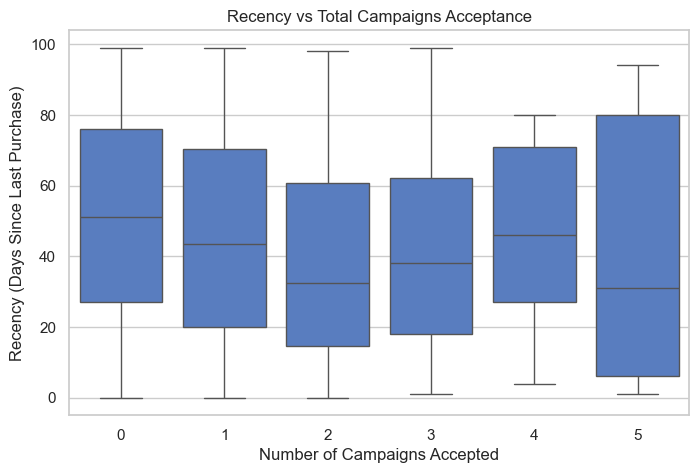

In [75]:
# Recency vs Campaign Response

plt.figure(figsize = (8,5))

sns.boxplot(x= 'TotalCampaignAccepted', y= 'Recency', data = food)
plt.title('Recency vs Total Campaigns Acceptance')
plt.xlabel('Number of Campaigns Accepted')
plt.ylabel('Recency (Days Since Last Purchase)')
plt.show()

Customers who accepted **2-3 campaigns show the lowest recency** (most recent purchases), suggesting active buyers engage most with campaigns. Interestingly, customers who accepted **4-5  campaigns show higher recency** again — these may be older loyal customers whose purchase frequency has slowed but who historically responded well to offers.

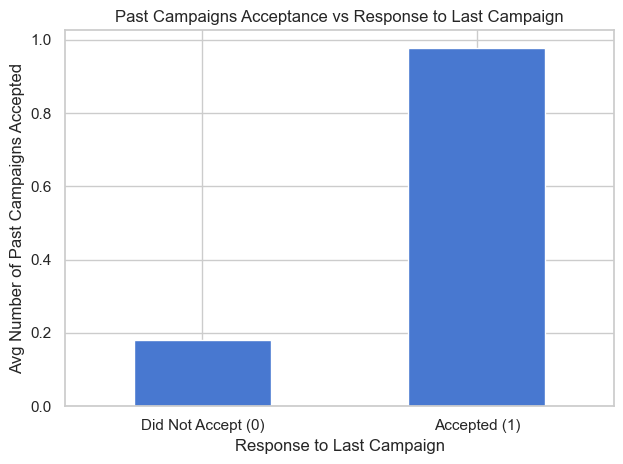

In [79]:
# Past Campaign Acceptance vs Last Campaign Response
past_vs_last = food.groupby('Response')['AcceptedCmpOverall'].mean().round(3)

past_vs_last.plot(kind = 'bar', title = 'Past Campaigns Acceptance vs Response to Last Campaign')
plt.ylabel('Avg Number of Past Campaigns Accepted')
plt.xlabel('Response to Last Campaign')
plt.xticks([0,1], ['Did Not Accept (0)', 'Accepted (1)'], rotation = 0)
plt.tight_layout()
plt.show()

Customers who accepted the last campaign had previously accepted **far more past campaigns** on average than those who did not. This strong difference suggests that **past campaign acceptance is a good predictor of responding to the final campaign**—customers who engaged before are much more likely to engage again.

### Campaign Analysis — Conclusions

Campaign engagement across the customer base is low — 67% of customers accepted no campaigns at all, and only 9 customers accepted all 5.

However, a clear profile of the ideal campaign target emerges from the data:

- **Higher income**: Responders earn approximately $10000 or more per year
  
- **Higher spenders**: Responders spend nearly double

- **No kids**: Non-responders have an average of 1.01 children at home vs 0.65 for responders — households with children are significantly less likely to respond

- **Past behaviour predicts future behaviour**: Responders accepted nearly 1 past campaign on average, vs only 0.18 for non-responders — This is the strongest single predictor found in the analysis
  
- **Recent buyers engage more**: Customers who accepted 2–3 campaigns had the lowest recency, confirming that recently active customers are more campaign-responsive

**Business Recommendation**: UFood should prioritise campaign targeting toward high-income, child-free, recently active customers who have responded to at least one past campaign. Sending campaigns to the full customer base is wasteful — the data shows a concentrated group of responsive customers who can be identified in advance.

# Channel Analysis - Where Do Customers Buy?

UFood sells through three channels: stores, catalogues, and the website. Understanding which channel customers prefer — and whether different customer types use different channels — tells the business where to invest. For example, if high-income customers prefer catalogues, the catalogue budget should not be cut.

In [81]:
# Average Purchases per Channel 
channel_cols = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']

avg_channels = food[channel_cols].mean().sort_values(ascending = False)
avg_channels

NumStorePurchases      5.807521
NumWebPurchases        4.115289
NumCatalogPurchases    2.644730
NumDealsPurchases      2.330035
dtype: float64

In [82]:
total_channels = food[channel_cols].sum().sort_values(ascending = False)
total_channels

NumStorePurchases      11737
NumWebPurchases         8317
NumCatalogPurchases     5345
NumDealsPurchases       4709
dtype: int64

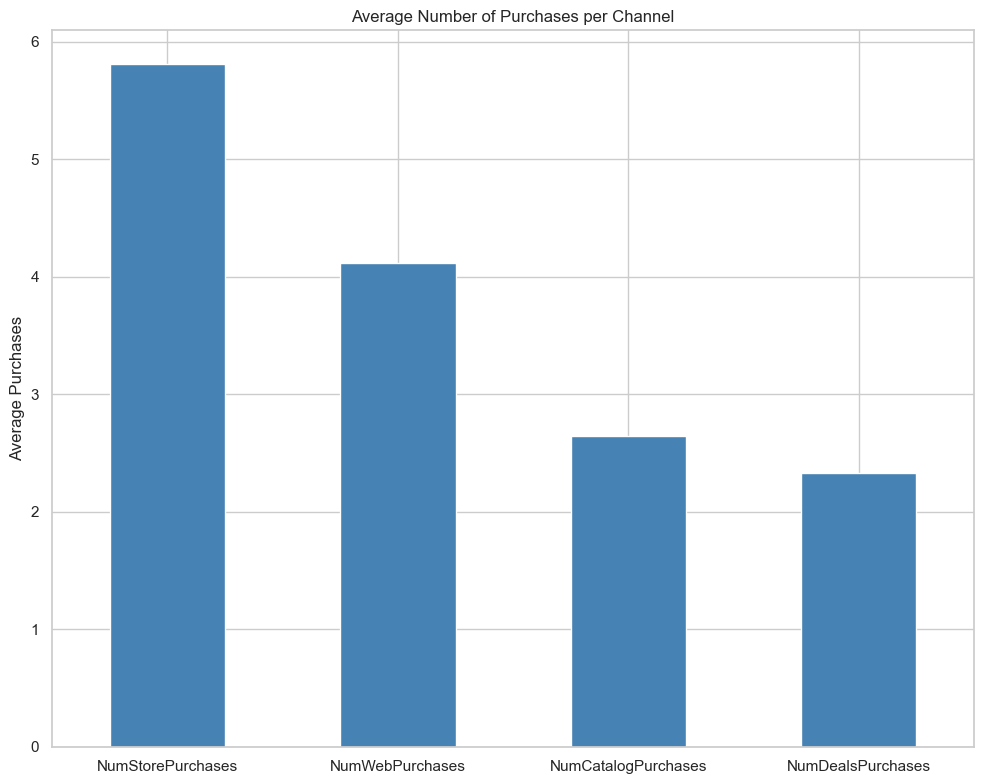

In [85]:
avg_channels.plot(kind = 'bar', figsize = (10,8), color = 'steelblue', title =('Average Number of Purchases per Channel'))
plt.ylabel('Average Purchases')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Store purchases are the most frequently used channel, followed by web purchases. Catalog and deal purchases are used far less often. Overall, customers clearly prefer **in‑store and online channels**, with catalog and deal-based purchases playing a smaller role in their buying behavior.

In [94]:
# Channel Usage by Income Group 
channel_by_income = food.groupby('IncomeGroup', observed = True)[channel_cols].mean().round(2)
channel_by_income

,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
IncomeGroup,,,,
Low,2.10,2.05,0.48,2.96
Mid-Low,2.75,3.39,1.17,4.21
Mid-High,3.07,5.63,3.28,7.62
High,1.40,5.39,5.65,8.45


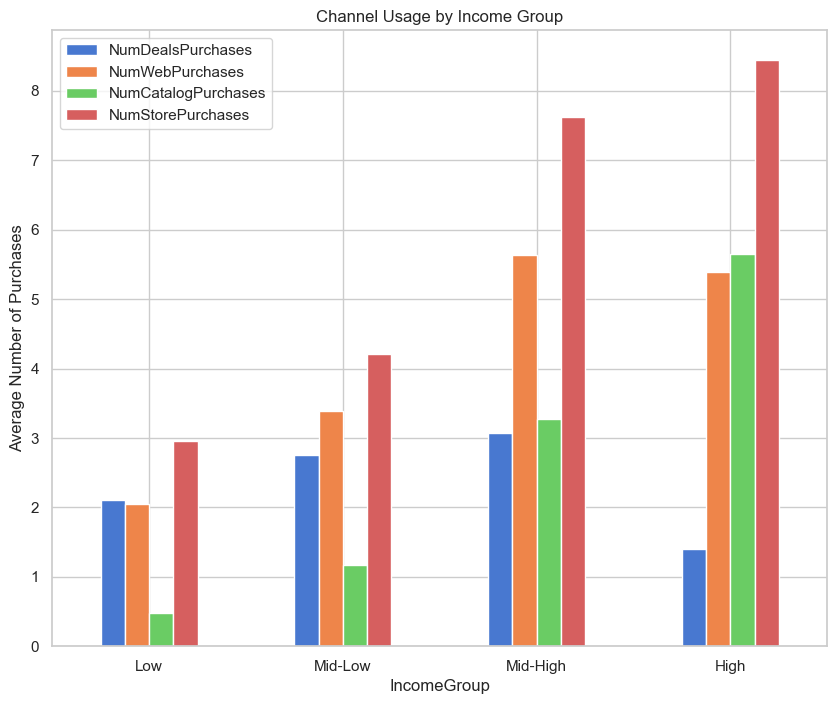

In [89]:
channel_by_income.plot(kind = 'bar', figsize = (10,8), title = 'Channel Usage by Income Group')
plt.ylabel('Average Number of Purchases')
plt.xticks(rotation = 0)
plt.show()

Channel usage increases steadily with income. Low‑income customers make the fewest purchases across all channels, especially catalog and web. Mid‑income groups show moderate growth, while high‑income customers stand out with the highest activity—particularly in store and catalog purchases. Overall, higher‑income customers are **more active, more multi‑channel, and more engaged**, indicating that income strongly influences purchasing behavior across every channel.

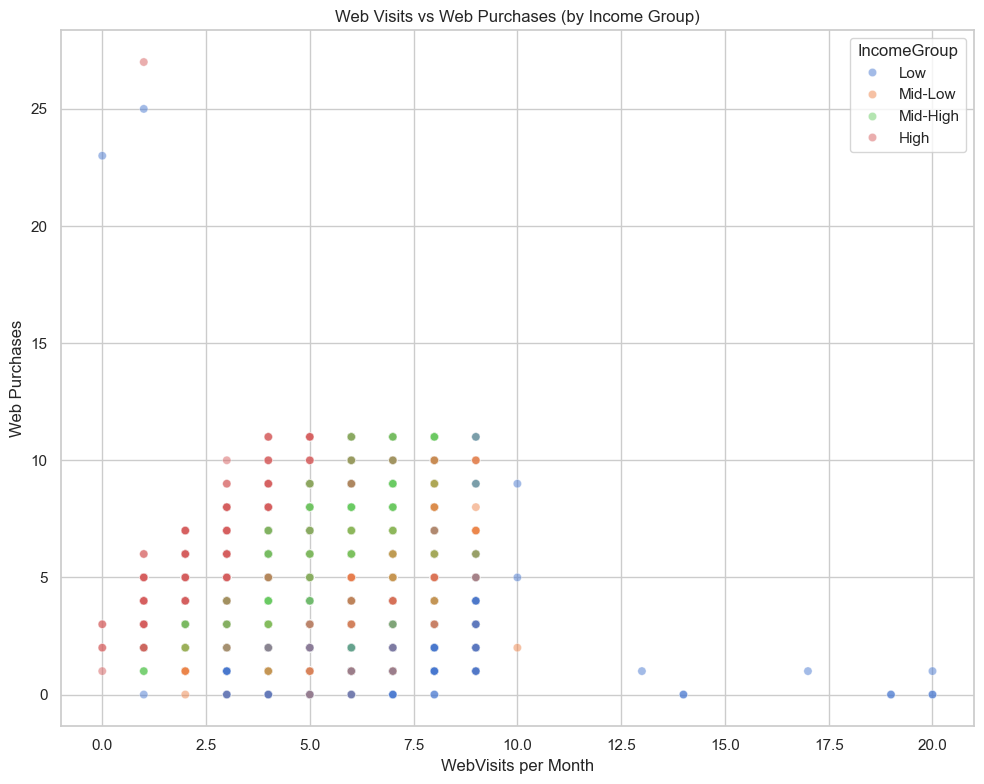

In [91]:
# Web Visits vs Web Purchases
plt.figure(figsize = (10,8))

sns.scatterplot(data = food, x= 'NumWebVisitsMonth', y= 'NumWebPurchases', hue = 'IncomeGroup', alpha = 0.5)
plt.title('Web Visits vs Web Purchases (by Income Group)')
plt.xlabel('WebVisits per Month')
plt.ylabel('Web Purchases')
plt.tight_layout()
plt.show()

In [93]:
# Checking the correlation between visits and purchases
food['NumWebVisitsMonth'].corr(food['NumWebPurchases'])

np.float64(-0.0563375211730403)

There is **no meaningful relationship** between web visits and web purchases. The scatterplot shows a wide, scattered cloud with no upward trend, and the correlation is **-0.056**, which is essentially zero. This means customers who visit the website more often **do not necessarily buy more**, regardless of income group.

### Channel Analysis — Conclusions

**Physical stores are the dominant purchase channel**, accounting for 5.8 average purchases per customer and 11,737 total transactions — significantly ahead of web (4.1 avg) and catalogue (2.6 avg).

**Channel preference shifts strongly with income:**
- High-income customers use stores and catalogues far more than low-income customers (8.45 vs 2.96 store purchases; 5.65 vs 0.48 catalogue purchases)
- Catalogue purchasing is almost exclusively a high-income behaviour 
- Discount purchases (NumDealsPurchases) decline as income rises, suggesting low-income customers are more price-sensitive and dependent on promotions

**Web channel has a conversion problem.** The correlation between website visits and web purchases is -0.056, near zero and slightly negative. Customers who visit the website frequently are not converting into buyers. This is particularly visible among low-income customers, who show high visit counts but low purchase volumes.

**Business Recommendations:**
1. Maintain and invest in physical store experience — it is the primary revenue channel across all income groups
2. Catalogue campaigns should be directed at high-income segments where uptake is highest
3. The website requires conversion optimisation — more visits are not translating into more purchases, suggesting friction in the online buying experience (poor UX, limited online offers, or customers browsing then buying in-store instead)
4. Discount-heavy campaigns are best targeted at low and mid-low income segments where deal sensitivity is highest

# Correlation Analysis

Correlation tells you how strongly two numeric columns move together. A correlation of +1 means they move perfectly together (as one goes up, the other does too). A correlation of -1 means they move perfectly in opposite directions. 0 means no relationship. A heatmap lets you see all correlations at once — it is one of the most powerful tools in a data analyst's toolkit for quickly spotting relationships

In [105]:
# Correlation Heatmap

numeric_cols = ['Income','Response', 'Recency', 'NumWebVisitsMonth', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'Age', 'TotalCampaignAccepted', 'TotalSpend', 'HasKids']

In [106]:
corr_matrix = food[numeric_cols].corr()
corr_matrix

,Income,Response,Recency,NumWebVisitsMonth,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Age,TotalCampaignAccepted,TotalSpend,HasKids
Income,1.000000,0.175167,0.001105,-0.643992,-0.135717,0.495144,0.705481,0.684358,0.216372,0.364317,0.819310,-0.356096
Response,0.175167,1.000000,-0.203954,-0.005581,-0.000464,0.145522,0.233975,0.030087,-0.026153,0.724772,0.263553,-0.175340
Recency,0.001105,-0.203954,1.000000,-0.011966,0.009301,-0.005093,0.018353,-0.000854,0.013426,-0.094823,0.014006,0.029236
NumWebVisitsMonth,-0.643992,-0.005581,-0.011966,1.000000,0.363911,-0.056338,-0.522821,-0.444680,-0.125307,-0.127355,-0.491660,0.408092
NumDealsPurchases,-0.135717,-0.000464,0.009301,0.363911,1.000000,0.243263,-0.049526,0.068607,0.064622,-0.094730,-0.075178,0.437949
NumWebPurchases,0.495144,0.145522,-0.005093,-0.056338,0.243263,1.000000,0.414002,0.500646,0.161232,0.210574,0.528961,-0.162898
NumCatalogPurchases,0.705481,0.233975,0.018353,-0.522821,-0.049526,0.414002,1.000000,0.561754,0.141822,0.371265,0.794485,-0.456710
NumStorePurchases,0.684358,0.030087,-0.000854,-0.444680,0.068607,0.500646,0.561754,1.000000,0.143198,0.170550,0.678442,-0.335870
Age,0.216372,-0.026153,0.013426,-0.125307,0.064622,0.161232,0.141822,0.143198,1.000000,-0.017634,0.124660,0.087014
TotalCampaignAccepted,0.364317,0.724772,-0.094823,-0.127355,-0.094730,0.210574,0.371265,0.170550,-0.017634,1.000000,0.451852,-0.264298


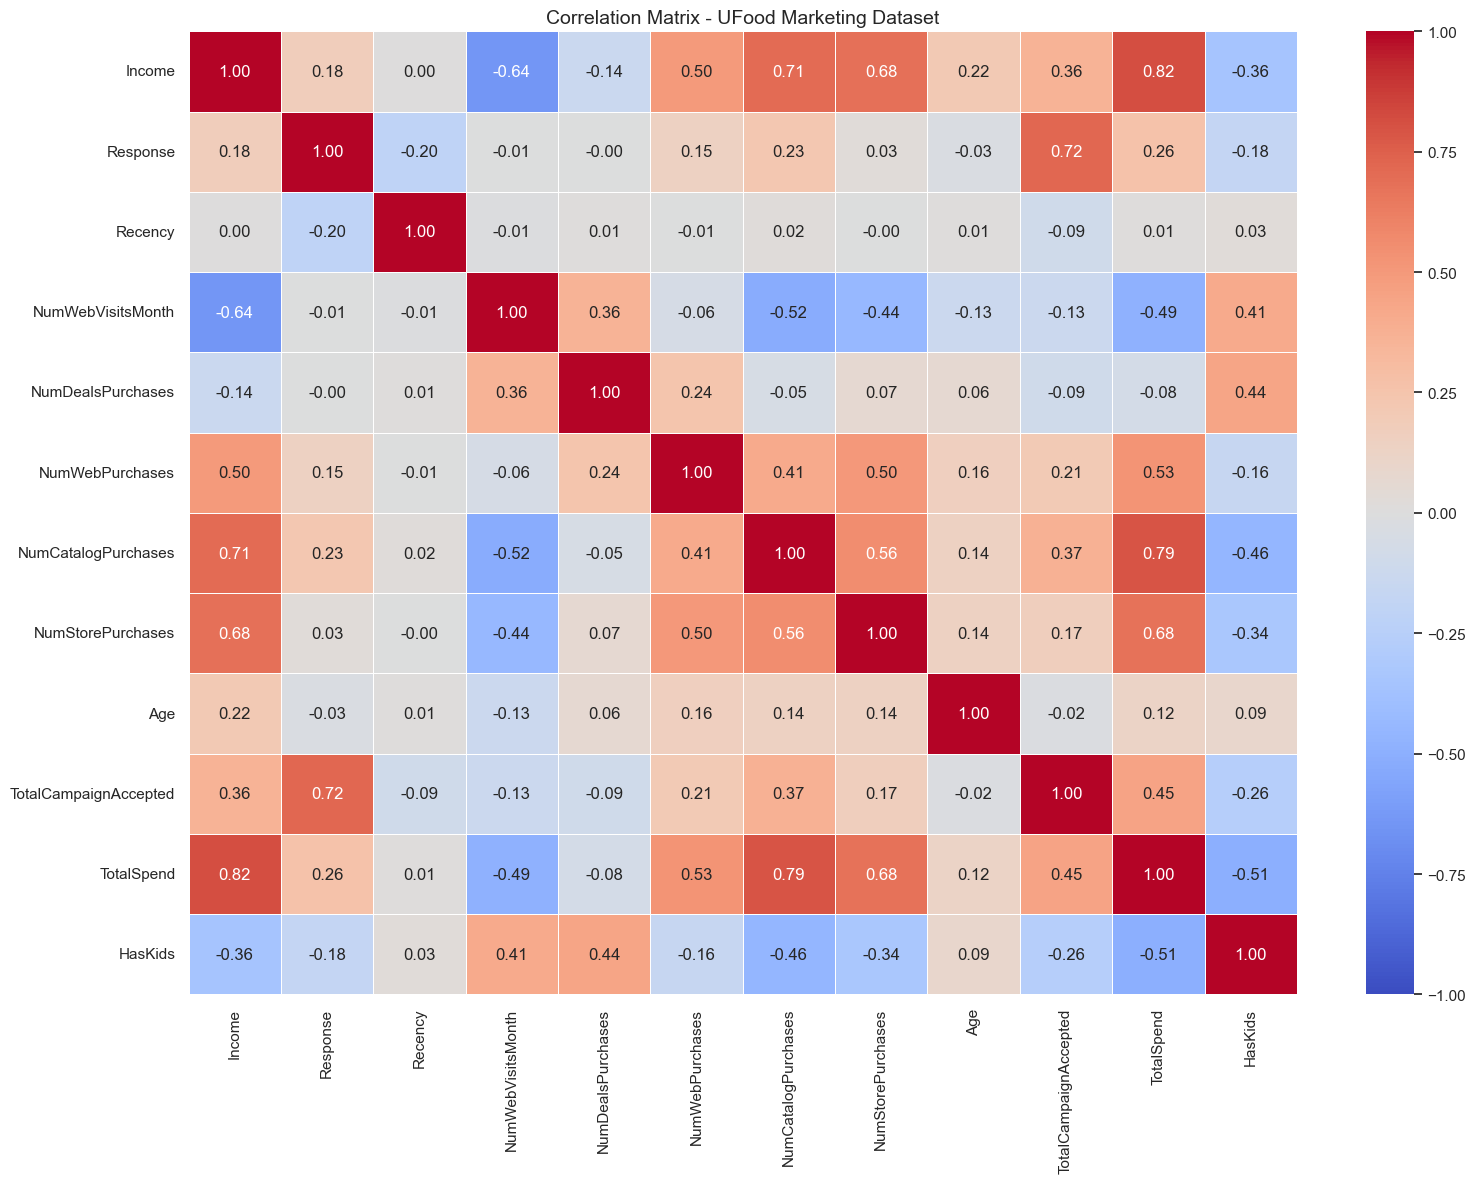

In [107]:
plt.figure(figsize = (16,12))

sns.heatmap(corr_matrix, 
           annot = True,
           fmt = '.2f',
           cmap= 'coolwarm',
           linewidths = 0.5,
           vmin = -1, vmax = 1)
plt.title('Correlation Matrix - UFood Marketing Dataset', fontsize = 14)
plt.tight_layout()
plt.show()

The correlation matrix shows that **Income**, **TotalSpend**, and **Store/Web/Catalog purchases** are strongly positively related — higher‑income customers tend to spend more and purchase more across all channels. **Recency** is negatively correlated with spending and purchases, meaning customers who bought recently tend to be more active overall. **TotalCampaignAccepted** also correlates positively with spending and purchase activity, indicating that more engaged customers respond to more campaigns. Most other correlations are weak, suggesting limited overlap between many behavioral variables.

In [103]:
# Key Correlations to look for
spend_corr = corr_matrix['TotalSpend'].sort_values(ascending = False)
spend_corr

TotalSpend               1.000000
Income                   0.819310
NumCatalogPurchases      0.794485
NumStorePurchases        0.678442
NumWebPurchases          0.528961
TotalCampaignAccepted    0.451852
Age                      0.124660
Recency                  0.014006
NumDealsPurchases       -0.075178
NumWebVisitsMonth       -0.491660
HasKids                 -0.505746
Name: TotalSpend, dtype: float64

In [108]:
response_corr = corr_matrix['Response'].sort_values(ascending = False)
response_corr

Response                 1.000000
TotalCampaignAccepted    0.724772
TotalSpend               0.263553
NumCatalogPurchases      0.233975
Income                   0.175167
NumWebPurchases          0.145522
NumStorePurchases        0.030087
NumDealsPurchases       -0.000464
NumWebVisitsMonth       -0.005581
Age                     -0.026153
HasKids                 -0.175340
Recency                 -0.203954
Name: Response, dtype: float64

Total spending is most strongly driven by **income** and **purchase activity** across catalog, store, and web channels. Customers who accept more campaigns also tend to spend more. When predicting campaign response, the strongest indicator is **TotalCampaignAccepted**, showing that customers who engaged with past campaigns are far more likely to accept the latest one. Other factors like age, recency, web visits, and having kids show weak or negative correlations, meaning they contribute very little to predicting spending or campaign response.

### Correlation Analysis — Conclusions

**Income is the single strongest driver of total spend (r = 0.82).**  As income rises, customers spend significantly more across all categories. This is the most important relationship in the dataset.

**Past campaign behaviour is the strongest predictor of future campaign response (r = 0.72).** A customer who accepted previous campaigns is far more likely to accept the next one. This is the most actionable finding for the marketing team — targeting past responders first is the most efficient use of campaign budget.

**Having kids at home negatively impacts both spend and response.**  HasKids correlates -0.51 with TotalSpend and -0.18 with Response. Households with children have less disposable income and less engagement with campaigns.

**Catalogue purchasing is a high-value behaviour (r = 0.79 with TotalSpend).** Catalogue customers are among the highest spenders and are also more likely to respond to campaigns (r = 0.23 with Response). This channel should not be reduced.

**The website has a conversion problem confirmed by correlation.**  NumWebVisitsMonth correlates -0.49 with TotalSpend and -0.64 with Income — lower-income customers visit the site frequently but convert poorly into purchases. High-income customers prefer stores and catalogues over the website.

**Recency has almost no linear correlation with spend or channels.**  While recency does predict campaign response (-0.20), it does not predict how much a customer spends overall. Recency is a measure of engagement timing, not value.

# Customer Segmentation - Group Your Customers

Segmentation means grouping customers who behave similarly together. Instead of treating 2,000+ customers the same way, we create 3-5 distinct groups and design different strategies for each. We use a simple income + spend rule to create 4 meaningful segments. This is called rule-based segmentation — the easiest and most explainable method, perfect for a beginner project.

We split the customers into 4 groups based on income and total spend:

1.  High income + High spend = Premium Customer

2.  High income + Low spend = Potential Customer (earns well but does not spend much)

3.  Low income + High spend = Bargain Hunter (spends a lot relative to income)

4.  Low income + Low spend = Budget Customer

In [109]:
income_median = food['Income'].median()
spend_median = food['TotalSpend'].median()

In [110]:
def assign_segment(row) :
    high_income = row['Income'] >= income_median
    high_spend = row['TotalSpend'] >= spend_median
    if high_income and high_spend:
        return 'Premium'
    elif high_income and not high_spend:
        return 'Potential'
    elif not high_income and high_spend:
        return 'Bargain Hunter'
    else:
        return 'Budget'

In [113]:
food['Segment'] = food.apply(assign_segment, axis = 1)

In [114]:
food['Segment'].value_counts()

Segment
Premium           899
Budget            896
Bargain Hunter    114
Potential         112
Name: count, dtype: int64

In [119]:
# What does the average customer look like in each segment?
profile_cols = ['Income', 'Age', 'TotalSpend', 'HasKids', 'TotalCampaignAccepted']
segment_profile = food.groupby('Segment')[profile_cols].mean().round(2)
segment_profile

,Income,Age,TotalSpend,HasKids,TotalCampaignAccepted
Segment,,,,,
Bargain Hunter,43503.02,51.61,601.60,0.94,0.47
Budget,32970.76,48.48,100.80,1.24,0.20
Potential,57975.46,54.43,213.34,1.43,0.09
Premium,70595.72,53.28,1162.84,0.61,0.76


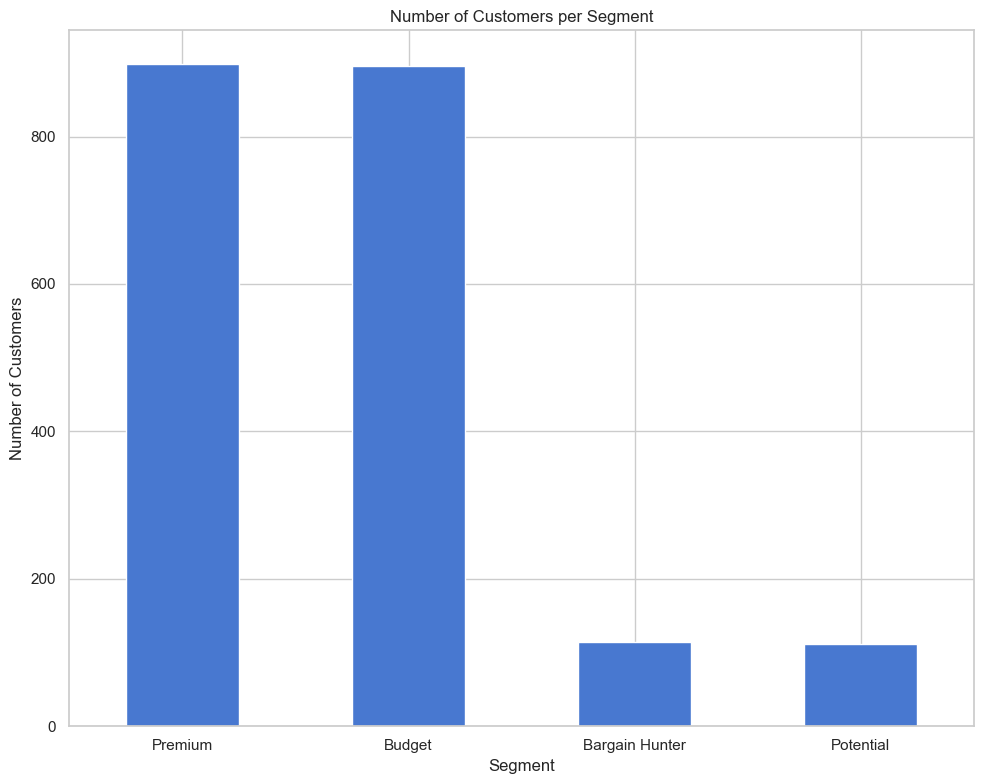

In [121]:
# How many customers are in each segment?
segment_counts = food['Segment'].value_counts()

segment_counts.plot(kind = 'bar', figsize = (10,8), title = 'Number of Customers per Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

The chart shows how many customers fall into each of the four segments created from income and spending levels. **Premium** and **Budget** segments make up the largest portions of the customer base, while **Bargain Hunters** and **Potential** customers are much smaller groups. This distribution highlights that most customers are either high‑value Premium buyers or low‑income Budget shoppers, with fewer customers in the mid‑range opportunity segments.

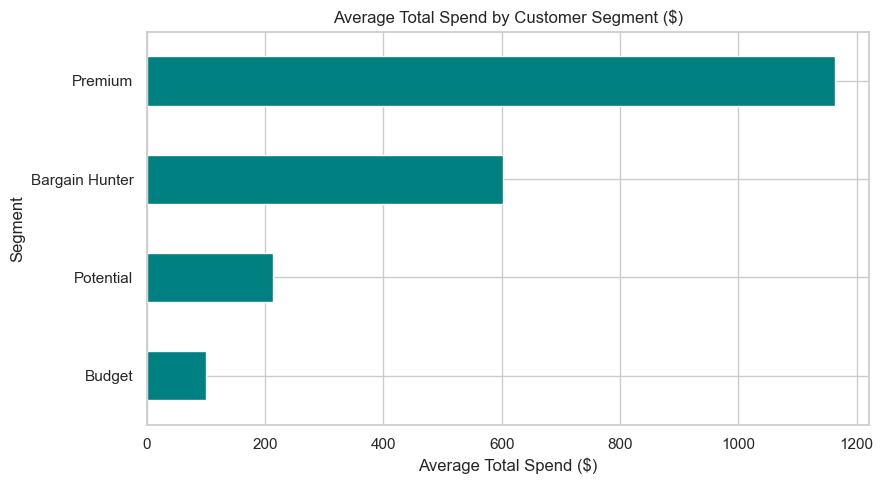

In [145]:
# Average total spend per segment
food.groupby('Segment')['TotalSpend'].mean().sort_values().plot(kind='barh', figsize=(9,5), color='teal', title='Average Total Spend by Customer Segment ($)')
plt.xlabel('Average Total Spend ($)')
plt.tight_layout()
plt.show()


The chart compares the average total spending across the four customer segments. **Premium** customers spend the most by a wide margin, followed by **Bargain Hunters**, who have lower income but still spend heavily. **Potential** customers spend moderately despite having higher income, while **Budget** customers spend the least. Overall, the visualization highlights clear spending differences between segments, with Premium customers being the most valuable group.

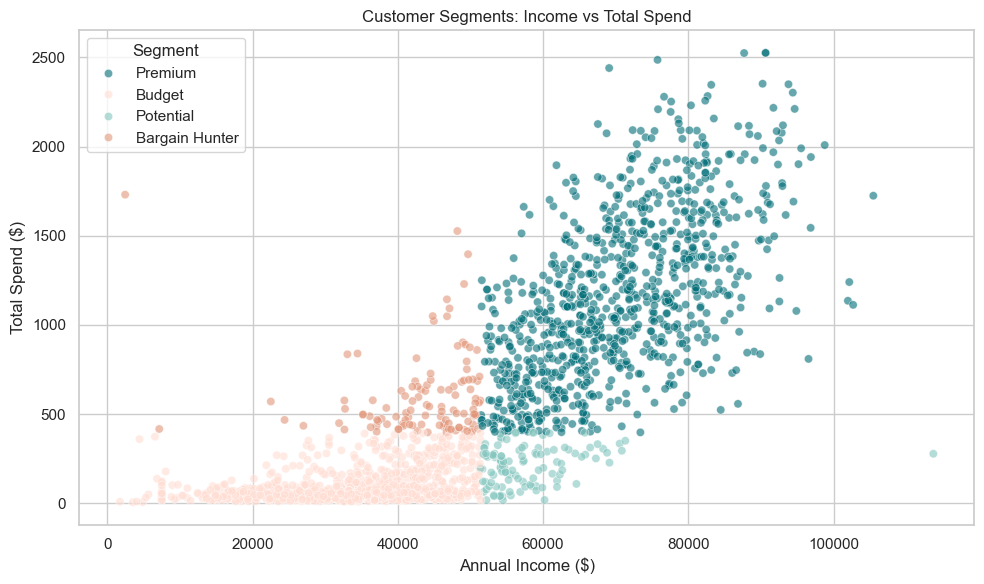

In [144]:
# Scatter plot: Income vs Total Spend
plt.figure(figsize=(10, 6))
palette = {'Premium':'#006D77', 'Potential':'#83C5BE',
'Bargain Hunter':'#E29578', 'Budget':'#FFDDD2'}
sns.scatterplot(x='Income', y='TotalSpend', hue='Segment',
data=food, palette=palette, alpha=0.6)
plt.title('Customer Segments: Income vs Total Spend')
plt.xlabel('Annual Income ($)')
plt.ylabel('Total Spend ($)')
plt.tight_layout()
plt.show()

The scatter plot shows how customer segments differ in income and total spending. Premium customers cluster in the **high‑income, high‑spend** area, while Budget customers sit in the **low‑income, low‑spend** range. Bargain Hunters have **low income but relatively high spending**, and Potential customers have **high income but lower spending**. The clear separation of clusters confirms that the segmentation logic accurately reflects real customer behavior.

### Customer Segmentation — Conclusions

Using income and total spend as the two defining dimensions, 
four distinct customer segments were identified:

**Premium (~900 customers | Avg Income: $70,596 | Avg Spend: $1,163)**  
The highest-value segment. These customers earn the most and spend 
the most, have fewer kids (HasKids avg = 0.61), and are the most 
campaign-responsive (0.76 campaigns accepted on average).  
→ Strategy: Reward loyalty, offer exclusive products, target with 
premium campaigns first.

**Budget (~900 customers | Avg Income: $32,971 | Avg Spend: $101)**  
The largest segment by count but the lowest value. Low income and 
near-zero discretionary spend. The highest HasKids average (1.24) 
suggests family expenses dominate their budget.  
→ Strategy: Low campaign priority. If targeted, use discount-driven 
offers only. High cost-to-acquire relative to return.

**Bargain Hunter (~110 customers | Avg Income: $43,503 | Avg Spend: $602)**  
A small but interesting segment — they spend significantly above 
what their income would predict. These customers are engaged and 
value-driven. Their campaign acceptance (0.47) is moderate.  
→ Strategy: Target with deals and promotions. They respond to value 
offers and already have high purchase intent.

**Potential (~105 customers | Avg Income: $57,975 | Avg Spend: $213)**  
The most underperforming segment relative to their income. They earn 
well but spend very little — the highest HasKids average (1.43) 
suggests family costs are suppressing discretionary spending. 
Their campaign acceptance is the lowest of all four groups (0.09).  
→ Strategy: Long-term opportunity. As their children grow older 
and disposable income increases, personalised re-engagement 
campaigns could convert them into Premium customers.

**Key Segmentation Insight**  
The scatter plot confirms that income alone does not determine 
spending behaviour — the Bargain Hunter segment spends far above 
its income level, while the Potential segment does the opposite. 
This means targeting campaigns purely by income would miss 
important behavioural differences. A combined income + spend 
segmentation gives a more complete and actionable picture.

# Final Conclusion & Business Recommendations

## Research Questions — Answered

**Q1. Which customer segments spend the most money?**

Premium customers are the highest spenders by a substantial margin. Income is the primary driver of this difference, with a correlation of 0.82 between income and total spend. 

**Q2. What customer traits predict campaign acceptance?**

The strongest predictor of campaign acceptance is past campaign behaviour — customers who accepted the last campaign had accepted nearly 1 previous campaign on average, versus only 0.18 for non-responders (correlation: 0.72 with Response).

**Q3. Which product categories drive the most revenue?**

Wines are the dominant product category, accounting for the largest share of average customer spend, followed by meat products. Fruits, sweet products, and fish products are all significantly lower. Gold (premium) products contribute moderately. This means wine and meat promotions would have the broadest revenue impact across the customer base, while gold products represent an upsell opportunity for the Premium segment specifically.

**Q4. Which purchase channels are most used?**

Physical stores are the most used channel overall, averaging 5.8 purchases per customer and 11,737 total transactions — well ahead of web (4.1 avg) and catalogue (2.6 avg). However, channel preference shifts significantly with income. High-income customers are multi-channel and particularly active in stores (8.45 avg) and catalogues (5.65 avg), while low-income customers rely more on web visits and deal purchases. The web channel shows a conversion problem — a correlation of -0.056 between website visits and purchases confirms that more visits are not translating into more sales.

**Q5. How do discount-heavy buyers differ from full-price buyers?**

Discount purchase frequency (NumDealsPurchases) actually declines as income rises — low-income customers average 2.10 deal purchases versus 1.40 for high-income customers. This confirms that deal-driven purchasing is concentrated among lower-income, more price-sensitive segments. Discount purchases also correlate negatively with total spend (-0.08), suggesting that heavy deal users are not the highest value customers. Discount campaigns should be reserved for the Budget and Mid-Low income segments where they have the most influence on purchase behaviour.

**Q6. Can customers be grouped into meaningful segments?**

Yes. Using income and total spend as the two defining dimensions, four distinct and well-separated customer segments were identified:

- **Premium** (~900 customers): High income, high spend — the core revenue engine
- **Budget** (~900 customers): Low income, low spend — large in count but low in value
- **Bargain Hunter** (~110 customers): Low income, high spend — deal-driven but engaged
- **Potential** (~105 customers): High income, low spend — the biggest untapped opportunity

The scatter plot of Income vs Total Spend confirms that these four segments separate clearly in two-dimensional space, validating that the segmentation logic reflects real and meaningful behavioural differences in the customer base.

## Hypotheses — Evaluated

**H1: Higher-income customers spend more across all categories.** CONFIRMED
The correlation between Income and TotalSpend is 0.82 — one of the strongest relationships in the entire dataset. This holds true across every product category and every purchase channel. Income is the single most reliable predictor of customer value.

**H2: Customers with children at home accept fewer campaigns.** CONFIRMED
Non-responders to the last campaign had an average HasKids value of 1.01, compared to 0.65 for responders. The correlation between HasKids and Response is -0.18, and between HasKids and TotalSpend is -0.51. Households with children have less disposable income and lower engagement with marketing campaigns across the board. The Potential segment, which has the highest HasKids average (1.43), also has the lowest campaign acceptance of any segment (0.09).

**H3: Customers who accepted more past campaigns are more likely to accept the last one.** CONFIRMED — and this is the strongest finding in the project.
The correlation between TotalCampaignAccepted and Response is 0.72. Customers who accepted the last campaign had engaged with nearly 1 previous campaign on average, versus only 0.18 for those who did not. Past behaviour is by far the most reliable predictor of future campaign response.

**H4: Lower recency (bought recently) is linked to higher campaign 
acceptance.** CONFIRMED
The correlation between Recency and Response is -0.20, confirming that customers who purchased more recently are more likely to respond to campaigns. The boxplot analysis shows that customers who accepted 2–3 campaigns had the lowest median recency, meaning the most active recent buyers are also the most campaign-responsive. Recency does not predict total spend, but it does predict engagement timing. 

**H5: Catalogue buyers have a higher average total spend than web or store buyers.** CONFIRMED
NumCatalogPurchases has the second-highest correlation with TotalSpend at 0.79, behind only Income (0.82) and ahead of NumStorePurchases (0.68) and NumWebPurchases (0.53). Catalogue purchasing is almost exclusively a high-income behaviour — low-income customers average only 0.48 catalogue purchases versus 5.65 for high-income customers. Catalogue buyers are UFood's highest-value customers.

**H6: Education level influences which product categories customers prefer.** PARTIALLY SUPPORTED — but inconclusive in this analysis.
The dataset encodes education as one-hot dummy columns, making direct category-level groupby comparisons complex. While income correlates strongly with spending across all categories, education level beyond income does not emerge as a strong independent driver in the correlations examined. This hypothesis would benefit from further analysis — for example, a crosstab of education group against product category preference — which could be explored in a follow-up analysis.

## Business Recommendations

**1. Prioritise the Premium segment in every campaign**
Premium customers represent the most cost-efficient campaign target. UFood should invest in loyalty rewards, early access to new products, and exclusive offers for this segment.

**2. Use past campaign acceptance as the primary targeting filter**
With a correlation of 0.72 between past campaign acceptance and Response, the single most effective improvement UFood can make to its campaign strategy is to filter its contact list to customers who have accepted at least one previous campaign. Sending campaigns to the 
full customer base is wasteful — 67% of customers accepted zero campaigns, and many of them are unlikely to respond regardless of the offer.

**3. Do not reduce the catalogue channel**
Catalogue purchasing correlates 0.79 with total spend and 0.23 with campaign response. High-income customers — UFood's most valuable segment — are the primary catalogue users. Any budget cuts to the catalogue channel would disproportionately impact the Premium segment and risk reducing engagement from the company's highest-value customers.

**4. Invest in website conversion optimisation**
The correlation between web visits and web purchases is -0.056 — effectively zero. Lower-income customers visit the website frequently but are not converting into buyers. Before spending more on driving web traffic, UFood should investigate the causes of poor online conversion: the user experience, checkout friction, product presentation, or pricing competitiveness online versus in-store. Fixing conversion is more valuable than increasing traffic.

**5. Target the Potential segment with family-friendly campaigns**
The 105 Potential customers earn **57,975** on average but spend only $213 — the largest gap between income and spend in the entire dataset. 
Their high HasKids average (1.43) strongly suggests family costs are suppressing discretionary spend. Rather than writing this segment off, UFood should experiment with family-oriented promotions and lower-commitment offers. As these customers' children grow older and their disposable income increases, they represent the most realistic pipeline into the Premium segment.

**6. Reserve discount campaigns for lower-income segments**
Deal purchases decline as income rises. Offering discounts to Premium customers who would buy at full price anyway erodes margin without changing behaviour. Discount-driven campaigns should be targeted at the Budget and Bargain Hunter segments, where price sensitivity is highest and promotions are most likely to influence a purchase decision.